<a href="https://colab.research.google.com/github/Yasmina3/CBRA-FYP/blob/main/CBRA_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Passive synthetic time-series dataset

### Passive synthetic time-series generation

A passive time-series dataset was generated from the static 40-sensor thermal dataset by treating each original scenario as a **baseline equilibrium state** and simulating a **30-minute monitoring session** sampled every **30 seconds**. This produced **61 time points per scenario**. The temporal behavior was generated by adding small passive fluctuations around the baseline, including a slow acclimatization-like decay, very-low-frequency physiological oscillations, gradual ambient/camera drift, and low-amplitude sensor noise. The original static values were preserved exactly at **t = 0**, so each generated sequence remains anchored to the source scenario.

### Main assumptions

The passive protocol assumes that no external thermal provocation is applied. The subject is considered to be under relatively stable room conditions, with only mild thermal drift and slow physiological variability. Skin emissivity is commonly approximated near **0.98** in thermographic practice, and thermal cameras typically exhibit noise on the order of tens of millikelvin, so the synthetic noise and drift were kept deliberately small. A stabilization or acclimatization period on the order of minutes is commonly recommended in thermographic measurements, which motivates the use of a slow relaxation component.

### Important technical note

With a sampling interval of **30 seconds**, the highest representable frequency is **1 / (2 × 30) = 0.0167 Hz**. For that reason, only very-low-frequency oscillations were included. Faster physiological oscillations cannot be represented correctly at this sampling rate and would be aliased.

### Pros

This approach is simple, fast, reproducible, and preserves the original static scenarios exactly at the initial time point. It is suitable for creating a first multivariate thermal time-series dataset for experimentation, benchmarking, and method development. It also stays close to a passive monitoring interpretation rather than inventing strong thermal events.

### Cons

This method does **not** recover true transient physics from the original COMSOL data. It generates plausible passive dynamics around static anchors, but the temporal evolution is assumption-driven. It therefore cannot replace real measurements or true transient simulations. If higher realism is required, especially for recovery dynamics or stress protocols, transient bioheat simulation or real temporal reference data would still be needed. Dynamic thermography studies and bioheat modeling show that true recovery behavior is strongly shaped by perfusion, boundary conditions, and protocol design.

## How one case is transformed into a time series

For one case, the time series is generated by taking the original **static thermal measurement** as the starting point, then adding **small realistic temporal variations** around it.

The original row already contains the temperatures of the 40 sensors:

* `s_1, s_2, ..., s_40`

These values are treated as the **baseline temperature state** of that scenario.

In other words, the original static row becomes the first time point of the sequence.

---

## Step 1: Define the baseline

Let $B_j$ be the baseline temperature of sensor $j$.

Then, at the initial time:

$$
T_j(0) = B_j
$$

where:

* $T_j(t)$ is the temperature of sensor $j$ at time $t$
* $B_j$ is the original static temperature of sensor $j$

This means the generated time series is **exactly anchored** to the source data at $t=0$.

---

## Step 2: Add the time grid

A passive monitoring session is simulated over **30 minutes**, with one measurement every **30 seconds**.

So the time points are:

$$
t = 0, 30, 60, \dots, 1800 \text{ seconds}
$$

This gives:

$$
61 \text{ time steps}
$$

Thus, one static case is transformed into a matrix of shape:

$$
61 \times 40
$$

where:

* rows = time steps
* columns = sensors

---

## Step 3: Add a slow relaxation component

A small smooth trend is added to mimic slow thermal stabilization or acclimatization during passive observation.

This component is modeled using an exponential-type function:

$$
R(t) = A \left(e^{-t/\tau} - 1\right)
$$

where:

* $A$ is a small amplitude
* $\tau$ is a time constant controlling how fast the variation evolves

This form is useful because at $t=0$:

$$
R(0) = A(1 - 1) = 0
$$

So the signal still starts exactly at the original baseline.

---

## Step 4: Add slow oscillations

Real thermal signals are not perfectly constant. Even in passive measurements, small smooth oscillations may appear due to physiological or environmental variability.

A sinusoidal term is used:

$$
O(t) = a \sin(2\pi f t + \phi)
$$

where:

* $a$ is a small amplitude
* $f$ is a low frequency
* $\phi$ is the phase

In practice, one or more low-frequency oscillations can be combined to create smooth and realistic fluctuations.

---

## Step 5: Add slow drift

A passive recording may also contain a very small drift over time due to room conditions, device drift, or other gradual effects.

### Linear drift

A simple linear term can be used:

$$
D_1(t) = mt
$$

where $m$ is a very small slope.

### Random-walk drift

A more flexible drifting behavior can be modeled as:

$$
D_2(t) = D_2(t-1) + \epsilon_t
$$

where $\epsilon_t$ is a small random increment.

This creates a gentle wandering effect instead of a perfectly straight line.

---

## Step 6: Add sensor-specific noise

Each sensor also receives a small noise component so that the data do not look perfectly smooth or artificially identical.

The noise is modeled with an autoregressive process of order 1:

$$
N_t = \phi N_{t-1} + \epsilon_t
$$

where:

* $\phi$ controls temporal smoothness
* $\epsilon_t$ is a small random perturbation

This makes the noise more realistic than independent white noise, because the value at one time step depends partially on the previous one.

---

## Final temperature model for one sensor

For one sensor $j$, the generated temperature at time $t$ is approximately:

$$
T_j(t) = B_j + R(t) + D(t) + L_j O(t) + N_j(t)
$$

where:

* $B_j$ is the original baseline temperature of sensor $j$
* $R(t)$ is the slow relaxation term
* $D(t)$ is the slow drift term
* $O(t)$ is the shared oscillation term
* $L_j$ is a sensor-specific loading factor
* $N_j(t)$ is the sensor-specific noise

This means that every sensor starts from its real baseline value and then evolves over time through a combination of small smooth components.

---

## Interpretation in simple terms

For each sensor, the method does the following:

1. starts from the original static temperature
2. keeps this value exactly at time $t=0$
3. adds a small smooth relaxation
4. adds a small low-frequency oscillation
5. adds a very small drift
6. adds a little realistic sensor noise

As a result, each sensor produces a smooth passive time series instead of remaining perfectly constant.

---

## Example

Suppose that for one case the baseline value of sensor `s_1` is:

$$
B_1 = 34.40^\circ C
$$

Then the generated sequence could look like:

* $t=0$ s $\rightarrow 34.400$
* $t=30$ s $\rightarrow 34.407$
* $t=60$ s $\rightarrow 34.403$
* $t=90$ s $\rightarrow 34.410$
* $\dots$
* $t=1800$ s $\rightarrow 34.389$

The values remain close to the original temperature, but vary slightly over time in a smooth and plausible way.

---

## Why the sensors do not evolve identically

If all sensors followed exactly the same temporal curve, the dataset would look artificial.

To avoid that:

* each sensor has its own baseline
* each sensor has its own small noise
* each sensor has its own loading factor on the shared oscillation

This makes the sensors evolve in a **correlated but non-identical** way.

---

## Important note

This approach uses **simple mathematical components**:

* exponential relaxation
* sinusoidal oscillations
* linear drift
* random-walk drift
* autoregressive noise

Therefore, the method is mathematically structured and reproducible.

However, it does **not** solve the full transient bioheat equation over time.
Instead, it generates a **plausible passive thermal sequence** around a known static thermal state.

---

## Summary

For one case, the simulation procedure is:

* take the original 40-sensor static temperatures as the baseline
* preserve them exactly at time $t=0$
* generate 60 additional time points
* at each time point, add:

  * a small relaxation component
  * a small oscillation
  * a slow drift
  * sensor-specific noise

The final result is a matrix of shape:

$$
61 \times 40
$$

representing a passive 30-minute thermal monitoring session.

---

## Final remark

This method does not recover true transient physical heat transfer.
It creates a **synthetic but plausible passive time series** anchored to the original static data using controlled mathematical rules.

This makes it suitable for experimentation, benchmarking, and multivariate time-series modeling, while remaining clearly identifiable as a synthetic reconstruction.


In [ ]:
# @title
import os
import json
import numpy as np
import pandas as pd

# =========================================================
# CONFIG
# =========================================================
ROOT = "/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature"

BASE_WIDE_CSV = os.path.join(
    ROOT,
    "constructed_40_sensor_dataset",
    "breast_40_sensors_dataset.csv"
)

OUTPUT_DIR = os.path.join(ROOT, "constructed_passive_timeseries_dataset")
os.makedirs(OUTPUT_DIR, exist_ok=True)

WIDE_TS_CSV = os.path.join(OUTPUT_DIR, "breast_passive_timeseries_wide.csv")
LONG_TS_CSV = os.path.join(OUTPUT_DIR, "breast_passive_timeseries_long.csv")
SUMMARY_JSON = os.path.join(OUTPUT_DIR, "passive_timeseries_summary.json")

# Time grid: 30 minutes, every 30 seconds => 61 samples
DURATION_SEC = 30 * 60
DT_SEC = 30
TIME_SEC = np.arange(0, DURATION_SEC + DT_SEC, DT_SEC)   # 0..1800
N_STEPS = len(TIME_SEC)

# Randomness
GLOBAL_SEED = 42

# Save long format too? (large but useful)
SAVE_LONG_FORMAT = True

# Optional quantization (set True if you want device-like rounding)
APPLY_QUANTIZATION = False
QUANTIZATION_STEP_C = 0.01  # e.g. 0.01°C

# =========================================================
# PASSIVE GENERATOR HYPERPARAMETERS
# =========================================================
# These are conservative passive-session assumptions.

# 1) Acclimatization-like common decay toward equilibrium
#    initial offset at t=0 is forced to 0 exactly, then a tiny decaying term is added
TAU_RELAX_MIN_SEC = 600      # 10 min
TAU_RELAX_MAX_SEC = 1200     # 20 min
RELAX_AMPLITUDE_STD_C = 0.035

# 2) Slow ambient / camera drift
#    implemented as linear drift + tiny random walk, both forced to start at 0
LINEAR_DRIFT_STD_C_PER_MIN = 0.0015   # around a few hundredths of °C over 30 min
RW_STEP_STD_C = 0.0025                # small step random walk

# 3) Very-low-frequency physiological oscillations
# IMPORTANT:
# With dt = 30 s, Nyquist frequency = 1/(2*30) = 0.0167 Hz
# So frequencies above 0.0167 Hz cannot be represented correctly.
# We therefore stay below that threshold.
N_SHARED_OSC = 2
OSC_FREQ_RANGE_HZ = (0.002, 0.012)    # periods ~ 83 s to 500 s
OSC_AMP_RANGE_C = (0.005, 0.020)

# 4) Sensor-specific loading of shared oscillations
SENSOR_LOADING_STD = 0.08

# 5) Sensor-specific AR(1)-like noise
SENSOR_NOISE_SIGMA_RANGE_C = (0.004, 0.012)
SENSOR_NOISE_PHI = 0.65

# 6) Small common camera noise
COMMON_NOISE_SIGMA_C = 0.004


# =========================================================
# HELPERS
# =========================================================
def quantize_temperature(x, step=0.01):
    return np.round(x / step) * step


def generate_random_walk(n, step_sigma, rng):
    x = np.zeros(n)
    for t in range(1, n):
        x[t] = x[t-1] + rng.normal(0, step_sigma)
    return x


def generate_ar1_noise(n, phi, sigma, rng):
    x = np.zeros(n)
    for t in range(1, n):
        x[t] = phi * x[t-1] + rng.normal(0, sigma)
    return x


def build_shared_oscillation(time_sec, rng):
    """
    Sum of a few very-low-frequency sinusoidal components.
    Forced to start at 0 by subtracting value at t=0.
    """
    osc = np.zeros_like(time_sec, dtype=float)

    for _ in range(N_SHARED_OSC):
        f = rng.uniform(*OSC_FREQ_RANGE_HZ)
        a = rng.uniform(*OSC_AMP_RANGE_C)
        phase = rng.uniform(0, 2*np.pi)
        osc += a * np.sin(2 * np.pi * f * time_sec + phase)

    osc = osc - osc[0]   # force exact zero at t=0
    return osc


def build_passive_sequence_for_one_scenario(base_sensor_values, time_sec, rng):
    """
    base_sensor_values: shape (40,)
    returns array of shape (N_STEPS, 40)
    """

    n_steps = len(time_sec)
    n_sensors = len(base_sensor_values)

    # -----------------------------------------------------
    # Common passive session components
    # -----------------------------------------------------

    # A) small acclimatization-like decay
    tau_relax = rng.uniform(TAU_RELAX_MIN_SEC, TAU_RELAX_MAX_SEC)
    relax_amp = rng.normal(0, RELAX_AMPLITUDE_STD_C)
    common_relax = relax_amp * (np.exp(-time_sec / tau_relax) - 1.0)
    # starts exactly at 0 because exp(0)-1 = 0

    # B) linear drift
    slope_c_per_min = rng.normal(0, LINEAR_DRIFT_STD_C_PER_MIN)
    common_linear = slope_c_per_min * (time_sec / 60.0)
    common_linear = common_linear - common_linear[0]

    # C) tiny random walk drift
    common_rw = generate_random_walk(n_steps, RW_STEP_STD_C, rng)
    common_rw = common_rw - common_rw[0]

    # D) shared physiological oscillation
    shared_osc = build_shared_oscillation(time_sec, rng)

    # E) tiny common measurement noise, forced to 0 at t=0
    common_noise = rng.normal(0, COMMON_NOISE_SIGMA_C, size=n_steps)
    common_noise[0] = 0.0

    common_component = common_relax + common_linear + common_rw + common_noise

    # -----------------------------------------------------
    # Sensor-specific components
    # -----------------------------------------------------
    sensor_loadings = np.clip(
        1.0 + rng.normal(0, SENSOR_LOADING_STD, size=n_sensors),
        0.75,
        1.25
    )

    all_series = np.zeros((n_steps, n_sensors), dtype=float)

    for j in range(n_sensors):
        sigma_j = rng.uniform(*SENSOR_NOISE_SIGMA_RANGE_C)
        sensor_noise = generate_ar1_noise(n_steps, SENSOR_NOISE_PHI, sigma_j, rng)
        sensor_noise[0] = 0.0  # exact anchor at t=0

        # Final passive signal around the static baseline
        series_j = (
            base_sensor_values[j]
            + common_component
            + sensor_loadings[j] * shared_osc
            + sensor_noise
        )

        if APPLY_QUANTIZATION:
            series_j = quantize_temperature(series_j, QUANTIZATION_STEP_C)

        all_series[:, j] = series_j

    # Force exact equality with baseline at t=0
    all_series[0, :] = base_sensor_values.copy()

    return all_series


# =========================================================
# LOAD BASE DATASET
# =========================================================
base_df = pd.read_csv(BASE_WIDE_CSV)

sensor_cols = [f"s_{i}" for i in range(1, 41)]
missing_sensor_cols = [c for c in sensor_cols if c not in base_df.columns]
if missing_sensor_cols:
    raise ValueError(f"Missing sensor columns in base dataset: {missing_sensor_cols}")

print("Base dataset shape:", base_df.shape)
print("Number of sensor columns:", len(sensor_cols))
print("Time steps to generate:", N_STEPS)

# Metadata columns = everything except sensors
meta_cols = [c for c in base_df.columns if c not in sensor_cols]

# =========================================================
# GENERATE PASSIVE TIME SERIES
# =========================================================
wide_rows = []
long_rows = []

rng_global = np.random.default_rng(GLOBAL_SEED)

for idx, row in base_df.iterrows():
    scenario_seed = int(rng_global.integers(0, 2**31 - 1))
    rng = np.random.default_rng(scenario_seed)

    base_values = row[sensor_cols].to_numpy(dtype=float)
    ts_matrix = build_passive_sequence_for_one_scenario(base_values, TIME_SEC, rng)
    # shape = (61, 40)

    # Base metadata preserved for every time step
    row_meta = {col: row[col] for col in meta_cols}
    row_meta["scenario_seed"] = scenario_seed
    row_meta["protocol"] = "passive"

    for t_idx, t_sec in enumerate(TIME_SEC):
        wide_row = row_meta.copy()
        wide_row["time_index"] = int(t_idx)
        wide_row["time_sec"] = int(t_sec)
        wide_row["time_min"] = float(t_sec / 60.0)

        for j, sname in enumerate(sensor_cols):
            wide_row[sname] = float(ts_matrix[t_idx, j])

        wide_rows.append(wide_row)

        if SAVE_LONG_FORMAT:
            for j, sname in enumerate(sensor_cols):
                long_rows.append({
                    **row_meta,
                    "time_index": int(t_idx),
                    "time_sec": int(t_sec),
                    "time_min": float(t_sec / 60.0),
                    "sensor_name": sname,
                    "temperature_c": float(ts_matrix[t_idx, j]),
                })

wide_ts_df = pd.DataFrame(wide_rows)
wide_ts_df.to_csv(WIDE_TS_CSV, index=False)

if SAVE_LONG_FORMAT:
    long_ts_df = pd.DataFrame(long_rows)
    long_ts_df.to_csv(LONG_TS_CSV, index=False)
else:
    long_ts_df = None

# =========================================================
# SUMMARY
# =========================================================
summary = {
    "protocol": "passive",
    "base_dataset_rows": int(len(base_df)),
    "base_dataset_columns": int(base_df.shape[1]),
    "sensor_columns_count": int(len(sensor_cols)),
    "time_step_seconds": int(DT_SEC),
    "duration_seconds": int(DURATION_SEC),
    "num_time_steps": int(N_STEPS),
    "wide_timeseries_shape": [int(wide_ts_df.shape[0]), int(wide_ts_df.shape[1])],
    "long_timeseries_shape": (
        [int(long_ts_df.shape[0]), int(long_ts_df.shape[1])]
        if long_ts_df is not None else None
    ),
    "apply_quantization": bool(APPLY_QUANTIZATION),
    "quantization_step_c": float(QUANTIZATION_STEP_C),
    "assumptions": {
        "relax_tau_range_sec": [TAU_RELAX_MIN_SEC, TAU_RELAX_MAX_SEC],
        "relax_amplitude_std_c": RELAX_AMPLITUDE_STD_C,
        "linear_drift_std_c_per_min": LINEAR_DRIFT_STD_C_PER_MIN,
        "random_walk_step_std_c": RW_STEP_STD_C,
        "oscillation_freq_range_hz": list(OSC_FREQ_RANGE_HZ),
        "oscillation_amp_range_c": list(OSC_AMP_RANGE_C),
        "sensor_loading_std": SENSOR_LOADING_STD,
        "sensor_noise_sigma_range_c": list(SENSOR_NOISE_SIGMA_RANGE_C),
        "sensor_noise_phi": SENSOR_NOISE_PHI,
        "common_noise_sigma_c": COMMON_NOISE_SIGMA_C,
        "global_seed": GLOBAL_SEED
    },
    "output_files": {
        "wide_timeseries_csv": WIDE_TS_CSV,
        "long_timeseries_csv": LONG_TS_CSV if SAVE_LONG_FORMAT else None,
    }
}

with open(SUMMARY_JSON, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("\n===== PASSIVE TIME-SERIES GENERATION FINISHED =====")
print(json.dumps(summary, indent=2))
print("\nSaved files:")
print(WIDE_TS_CSV)
if SAVE_LONG_FORMAT:
    print(LONG_TS_CSV)
print(SUMMARY_JSON)

Base dataset shape: (564, 57)
Number of sensor columns: 40
Time steps to generate: 61

===== PASSIVE TIME-SERIES GENERATION FINISHED =====
{
  "protocol": "passive",
  "base_dataset_rows": 564,
  "base_dataset_columns": 57,
  "sensor_columns_count": 40,
  "time_step_seconds": 30,
  "duration_seconds": 1800,
  "num_time_steps": 61,
  "wide_timeseries_shape": [
    34404,
    62
  ],
  "long_timeseries_shape": [
    1376160,
    24
  ],
  "apply_quantization": false,
  "quantization_step_c": 0.01,
  "assumptions": {
    "relax_tau_range_sec": [
      600,
      1200
    ],
    "relax_amplitude_std_c": 0.035,
    "linear_drift_std_c_per_min": 0.0015,
    "random_walk_step_std_c": 0.0025,
    "oscillation_freq_range_hz": [
      0.002,
      0.012
    ],
    "oscillation_amp_range_c": [
      0.005,
      0.02
    ],
    "sensor_loading_std": 0.08,
    "sensor_noise_sigma_range_c": [
      0.004,
      0.012
    ],
    "sensor_noise_phi": 0.65,
    "common_noise_sigma_c": 0.004,
    "globa

In [ ]:
# @title
import os
import json
import numpy as np
import pandas as pd

# =========================================================
# CONFIG
# =========================================================
ROOT = "/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature"

TS_DIR = os.path.join(ROOT, "constructed_passive_timeseries_dataset")
WIDE_TS_CSV = os.path.join(TS_DIR, "breast_passive_timeseries_wide.csv")

OUTPUT_DIR = os.path.join(ROOT, "constructed_passive_matrix_dataset")
os.makedirs(OUTPUT_DIR, exist_ok=True)

METADATA_CSV = os.path.join(OUTPUT_DIR, "metadata.csv")
TENSOR_NPY = os.path.join(OUTPUT_DIR, "timeseries_tensor.npy")
SENSOR_ORDER_JSON = os.path.join(OUTPUT_DIR, "sensor_order.json")
TIME_GRID_JSON = os.path.join(OUTPUT_DIR, "time_grid.json")
SUMMARY_JSON = os.path.join(OUTPUT_DIR, "matrix_dataset_summary.json")

MATRICES_DIR = os.path.join(OUTPUT_DIR, "scenario_matrices_npy")
os.makedirs(MATRICES_DIR, exist_ok=True)

# expected shape
EXPECTED_TIME_STEPS = 61
EXPECTED_SENSOR_COUNT = 40

# =========================================================
# LOAD
# =========================================================
df = pd.read_csv(WIDE_TS_CSV)

sensor_cols = [f"s_{i}" for i in range(1, EXPECTED_SENSOR_COUNT + 1)]
missing_sensor_cols = [c for c in sensor_cols if c not in df.columns]
if missing_sensor_cols:
    raise ValueError(f"Missing sensor columns: {missing_sensor_cols}")

required_cols = ["sample_id", "time_index", "time_sec", "time_min"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# metadata = everything except sensors and time columns that vary within scenario
meta_exclude = set(sensor_cols + ["time_index", "time_sec", "time_min"])
meta_cols = [c for c in df.columns if c not in meta_exclude]

# =========================================================
# VALIDATION
# =========================================================
scenario_ids = sorted(df["sample_id"].unique().tolist())
N = len(scenario_ids)

# check each scenario has 61 time steps
steps_per_scenario = df.groupby("sample_id")["time_index"].nunique()
bad_steps = steps_per_scenario[steps_per_scenario != EXPECTED_TIME_STEPS]
if len(bad_steps) > 0:
    raise ValueError(
        f"Some scenarios do not have {EXPECTED_TIME_STEPS} time steps:\n{bad_steps.head(20)}"
    )

# check global time grid
time_grid_df = (
    df[["time_index", "time_sec", "time_min"]]
    .drop_duplicates()
    .sort_values("time_index")
    .reset_index(drop=True)
)

if len(time_grid_df) != EXPECTED_TIME_STEPS:
    raise ValueError(
        f"Expected {EXPECTED_TIME_STEPS} unique time steps, found {len(time_grid_df)}"
    )

# =========================================================
# BUILD METADATA TABLE
# =========================================================
metadata_df = (
    df[meta_cols]
    .drop_duplicates(subset=["sample_id"])
    .sort_values("sample_id")
    .reset_index(drop=True)
)

if len(metadata_df) != N:
    raise ValueError(
        f"Metadata row count ({len(metadata_df)}) does not match number of scenarios ({N})"
    )

# =========================================================
# BUILD 3D TENSOR: (N, 61, 40)
# =========================================================
tensor = np.zeros((N, EXPECTED_TIME_STEPS, EXPECTED_SENSOR_COUNT), dtype=np.float32)

for i, sid in enumerate(scenario_ids):
    sub = df[df["sample_id"] == sid].copy().sort_values("time_index")

    # ensure time indices are exactly 0..60
    expected_idx = list(range(EXPECTED_TIME_STEPS))
    actual_idx = sub["time_index"].tolist()
    if actual_idx != expected_idx:
        raise ValueError(
            f"Scenario {sid} has unexpected time_index sequence.\n"
            f"Expected: {expected_idx[:10]}...\n"
            f"Actual:   {actual_idx[:10]}..."
        )

    mat = sub[sensor_cols].to_numpy(dtype=np.float32)  # shape (61, 40)
    if mat.shape != (EXPECTED_TIME_STEPS, EXPECTED_SENSOR_COUNT):
        raise ValueError(
            f"Scenario {sid} matrix shape mismatch: got {mat.shape}, "
            f"expected {(EXPECTED_TIME_STEPS, EXPECTED_SENSOR_COUNT)}"
        )

    tensor[i] = mat

    # save one matrix per scenario
    np.save(os.path.join(MATRICES_DIR, f"sample_{int(sid):04d}.npy"), mat)

# =========================================================
# SAVE OUTPUTS
# =========================================================
metadata_df.to_csv(METADATA_CSV, index=False)
np.save(TENSOR_NPY, tensor)

with open(SENSOR_ORDER_JSON, "w", encoding="utf-8") as f:
    json.dump(sensor_cols, f, indent=2)

with open(TIME_GRID_JSON, "w", encoding="utf-8") as f:
    json.dump(
        {
            "time_index": time_grid_df["time_index"].tolist(),
            "time_sec": time_grid_df["time_sec"].tolist(),
            "time_min": time_grid_df["time_min"].tolist(),
        },
        f,
        indent=2,
    )

summary = {
    "num_scenarios": int(N),
    "tensor_shape": [int(x) for x in tensor.shape],
    "matrix_shape_per_scenario": [EXPECTED_TIME_STEPS, EXPECTED_SENSOR_COUNT],
    "metadata_shape": [int(metadata_df.shape[0]), int(metadata_df.shape[1])],
    "time_grid_shape": [int(time_grid_df.shape[0]), int(time_grid_df.shape[1])],
    "sensor_count": EXPECTED_SENSOR_COUNT,
    "time_steps": EXPECTED_TIME_STEPS,
    "saved_files": {
        "metadata_csv": METADATA_CSV,
        "tensor_npy": TENSOR_NPY,
        "sensor_order_json": SENSOR_ORDER_JSON,
        "time_grid_json": TIME_GRID_JSON,
        "scenario_matrices_dir": MATRICES_DIR,
    },
}
with open(SUMMARY_JSON, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("===== MATRIX DATASET CONSTRUCTION FINISHED =====")
print(json.dumps(summary, indent=2))

===== MATRIX DATASET CONSTRUCTION FINISHED =====
{
  "num_scenarios": 564,
  "tensor_shape": [
    564,
    61,
    40
  ],
  "matrix_shape_per_scenario": [
    61,
    40
  ],
  "metadata_shape": [
    564,
    19
  ],
  "time_grid_shape": [
    61,
    3
  ],
  "sensor_count": 40,
  "time_steps": 61,
  "saved_files": {
    "metadata_csv": "/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature/constructed_passive_matrix_dataset/metadata.csv",
    "tensor_npy": "/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature/constructed_passive_matrix_dataset/timeseries_tensor.npy",
    "sensor_order_json": "/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature/constructed_passive_matrix_dataset/sensor_order.json",
    "time_grid_json": "/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature/constructed_passive_matrix_dataset/time_grid.json",


In [ ]:
import numpy as np

mat = np.load("/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature/constructed_passive_matrix_dataset/scenario_matrices_npy/sample_0001.npy")

print(mat.shape)
print(mat)

(61, 40)
[[33.891563 33.89151  33.891563 ... 34.82088  34.82089  34.820927]
 [33.915455 33.881424 33.92521  ... 34.848343 34.85923  34.829365]
 [33.94052  33.928547 33.947296 ... 34.859066 34.878735 34.85217 ]
 ...
 [33.855606 33.8327   33.873814 ... 34.805084 34.800552 34.793125]
 [33.838715 33.82574  33.834213 ... 34.777042 34.77095  34.76159 ]
 [33.851704 33.84935  33.845425 ... 34.7773   34.78462  34.769173]]


In [ ]:
import os
import numpy as np
import pandas as pd

MATRICES_DIR = "/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature/constructed_passive_matrix_dataset/scenario_matrices_npy"
CSV_DIR = "/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature/constructed_passive_matrix_dataset/scenario_matrices_csv"
os.makedirs(CSV_DIR, exist_ok=True)

sensor_cols = [f"s_{i}" for i in range(1, 41)]

for fname in sorted(os.listdir(MATRICES_DIR)):
    if fname.endswith(".npy"):
        mat = np.load(os.path.join(MATRICES_DIR, fname))
        df_mat = pd.DataFrame(mat, columns=sensor_cols)
        df_mat.insert(0, "time_index", range(len(df_mat)))

        csv_name = fname.replace(".npy", ".csv")
        df_mat.to_csv(os.path.join(CSV_DIR, csv_name), index=False)

print("All matrices exported to CSV.")

All matrices exported to CSV.


## How the cooling-recovery time series was generated

The original dataset contains **static thermal measurements** for 40 sensors.
Each row represents one simulation scenario and gives one temperature value for each sensor:

* `s_1, s_2, ..., s_40`

These values are interpreted as the **baseline temperature state before cooling**.

The goal of the reconstruction is to transform each static row into a **time series** representing what could happen if a cooling stimulus were applied and the tissue was then observed during recovery.

---

## General idea

For each original case:

1. the static 40-sensor row is taken as the **pre-cooling baseline**
2. a cooling step is simulated at the beginning of the sequence
3. the temperature is then allowed to **recover gradually toward baseline**
4. small realistic variations are added:

   * slow drift
   * low-frequency oscillations
   * sensor-specific noise

The result is a multivariate time series with:

* **61 time steps**
* **40 sensors**

So each original row becomes a matrix of shape:

$$
61 \times 40
$$

---

## Step 1: Define the baseline state

Let $B_j$ be the original static temperature of sensor $j$.

This value comes directly from the source dataset.

So for one case, the original baseline vector is:

$$
(B_1, B_2, B_3, \dots, B_{40})
$$

where each $B_j$ is one of the original sensor temperatures.

This baseline is interpreted as the **equilibrium temperature before cooling**.

---

## Step 2: Define the time grid

A recovery session of **30 minutes** is simulated, with one measurement every **30 seconds**.

So the time points are:

$$
t = 0, 30, 60, \dots, 1800 \text{ seconds}
$$

This gives:

$$
61 \text{ time steps}
$$

Thus, each scenario is expanded from one static row into a sequence over time.

---

## Step 3: Simulate the cooling effect at the beginning

The generated sequence starts **immediately after cooling removal**.

This means:

* the original static temperature is the **pre-cooling baseline**
* the first generated time point corresponds to the **cooled state**
* after that, the temperature rises back toward the baseline

For each sensor $j$, a cooling drop $\Delta_j$ is introduced.

So the signal begins below the baseline.

At the start of the recovery, the temperature is approximately:

$$
T_j(0) \approx B_j - \Delta_j
$$

where:

* $T_j(0)$ is the temperature at the first recovery instant
* $B_j$ is the baseline temperature
* $\Delta_j$ is the cooling-induced temperature drop for sensor $j$

This drop is not exactly the same for every sensor.
A common scenario-level cooling depth is sampled first, then small sensor-specific variations are added.

So the cooling is **globally coherent**, but not identical at every sensor.

---

## Step 4: Model the thermal recovery

After cooling, the signal should gradually return toward its baseline value.

To simulate this rewarming behavior, a **bi-exponential recovery model** is used.

The recovery profile is:

$$
R(t) = w , e^{-t/\tau_{\text{fast}}} + (1-w), e^{-t/\tau_{\text{slow}}}
$$

where:

* $\tau_{\text{fast}}$ is the fast recovery time constant
* $\tau_{\text{slow}}$ is the slow recovery time constant
* $w$ is the weight of the fast component

### Why use two exponentials?

Because thermal recovery is often not perfectly described by a single time scale.

A bi-exponential model allows:

* one fast part of recovery at the beginning
* one slower part later

This makes the recovery curve smoother and more realistic.

### Important property

At $t=0$:

$$
R(0) = w + (1-w) = 1
$$

So the full cooling drop is present at the beginning.

As $t$ increases:

$$
R(t) \to 0
$$

which means the signal gradually returns toward the baseline.

---

## Step 5: Final recovery formula

For one sensor $j$, the main reconstructed signal is:

$$
T_j(t) = B_j - \Delta_j R(t)
$$

This means:

* start below baseline by an amount $\Delta_j$
* then rise upward over time as $R(t)$ decays toward zero

If there were no drift, oscillations, or noise, the signal would be a clean recovery curve returning to baseline.

---

## Step 6: Add slow drift

Real thermal measurements are usually not perfectly stable.
Small session-wide drifts may occur because of:

* room conditions
* camera drift
* slight body adjustment
* imperfect stabilization

Two small drift components are added.

### Linear drift

A tiny linear trend is used:

$$
D_1(t) = mt
$$

where $m$ is a very small slope.

This allows the temperature to increase or decrease slightly over the session.

### Random-walk drift

A small random-walk term is also added:

$$
D_2(t) = D_2(t-1) + \epsilon_t
$$

where $\epsilon_t$ is a very small random increment.

This produces a soft wandering effect rather than a perfectly straight trend.

The total drift is then:

$$
D(t) = D_1(t) + D_2(t)
$$

---

## Step 7: Add low-frequency oscillations

In real recordings, signals often contain smooth fluctuations due to physiological or environmental effects.

To mimic this, a low-frequency oscillatory term is added:

$$
O(t) = a \sin(2\pi f t + \phi)
$$

where:

* $a$ is a small amplitude
* $f$ is a low frequency
* $\phi$ is the phase

Sometimes more than one oscillation is combined.

### Why low frequency only?

The sampling interval is **30 seconds**, so the signal cannot represent fast oscillations correctly.

Therefore, only **very slow oscillations** are included.

These act as smooth shared fluctuations over time.

---

## Step 8: Make sensors correlated but not identical

If every sensor followed exactly the same recovery curve, the data would look artificial.

To avoid this, each sensor has its own loading factor $L_j$ applied to the shared oscillation:

$$
L_j O(t)
$$

where:

* $L_j$ is slightly different for each sensor

This means:

* all sensors share a common oscillatory pattern
* but the amplitude is not identical across sensors

So the sensors evolve in a **correlated but non-identical** way.

---

## Step 9: Add sensor-specific noise

Each sensor also receives a small noise component to mimic measurement variability.

This noise is modeled with an autoregressive process of order 1:

$$
N_j(t) = \phi N_j(t-1) + \epsilon_t
$$

where:

* $\phi$ controls temporal smoothness
* $\epsilon_t$ is a small random perturbation

### Why AR(1) noise?

Because real sensor noise is usually not completely independent at each time point.

AR(1) noise gives a smoother and more realistic sequence than pure white noise.

---

## Final full model for one sensor

Combining everything, the temperature of sensor $j$ at time $t$ is modeled as:

$$
T_j(t) = B_j - \Delta_j R(t) + D(t) + L_j O(t) + N_j(t)
$$

where:

* $B_j$ is the original baseline temperature
* $\Delta_j$ is the cooling drop at that sensor
* $R(t)$ is the bi-exponential recovery profile
* $D(t)$ is the slow drift
* $O(t)$ is the shared oscillation
* $L_j$ is the sensor-specific oscillation loading
* $N_j(t)$ is the sensor-specific autoregressive noise

This is the main mathematical logic used to transform one static case into a cooling-recovery time series.

---

## Interpretation in simple words

For each original case, the following procedure is applied:

1. take the original 40-sensor temperatures as the **baseline**
2. assume a cooling stimulus has just been removed
3. lower the temperatures at the beginning by a realistic cooling amount
4. make the temperatures recover gradually back toward the baseline
5. add:

   * slow drift
   * smooth low-frequency oscillations
   * small sensor-specific noise

This produces a time series that behaves like a plausible thermal recovery sequence.

---

## Example of one sensor

Suppose the original baseline value of sensor `s_1` is:

$$
B_1 = 34.50^\circ C
$$

If the cooling drop is:

$$
\Delta_1 = 1.20^\circ C
$$

then the signal may start near:

$$
T_1(0) \approx 34.50 - 1.20 = 33.30^\circ C
$$

Then as time passes, the sensor gradually reheats:

* at the beginning: clearly below baseline
* after several minutes: closer to baseline
* near the end: close to the original temperature, but not perfectly flat because of drift and noise

So the curve may look like:

* $t=0$ s $\rightarrow 33.30$
* $t=30$ s $\rightarrow 33.45$
* $t=60$ s $\rightarrow 33.62$
* ...
* $t=1800$ s $\rightarrow 34.42$

This is only an example, but it shows the intended behavior:
a cooled signal that progressively returns toward the original thermal state.

---

## Healthy vs tumor assumption

A simplified assumption was introduced in the reconstruction:

* **healthy cases** were assigned somewhat slower recovery constants
* **tumor cases** were assigned somewhat faster recovery constants

This means that in the synthetic model, tumor-related cases tend to rewarm more quickly.

Mathematically, this is done by choosing different ranges for:

* $\tau_{\text{fast}}$
* $\tau_{\text{slow}}$

depending on the condition label.

This should be understood as a **modeling assumption**, not as a direct measurement extracted from the static dataset.

---

## Why this method was used

The original dataset is **not time series data**.
It contains only static thermal states.

Therefore, true temporal recovery cannot be directly observed from the available data.

The adopted solution was to generate a **synthetic but structured recovery process** that remains anchored to the original temperatures and follows a plausible thermal logic.

This approach was chosen because it:

* preserves the original baseline temperatures
* introduces realistic temporal evolution
* creates multivariate sequences suitable for time-series modeling
* remains simple enough to control and reproduce

---

## Main assumptions

The reconstruction relies on the following assumptions:

1. the original static row represents a **pre-cooling equilibrium state**
2. the generated sequence starts **immediately after cooling removal**
3. thermal recovery can be approximated by a **bi-exponential decay**
4. tumor cases may rewarm faster than healthy cases
5. small drift and oscillatory effects exist during the session
6. sensor noise is temporally correlated rather than purely random

These assumptions make the generated data plausible, but they remain synthetic assumptions.

---

## Advantages of this method

This reconstruction has several advantages:

* it transforms static cases into structured multivariate time series
* it keeps the original temperatures as physically meaningful anchors
* it follows a recovery-based logic that is closer to dynamic thermography than passive drift alone
* it produces smooth, interpretable curves
* it is reproducible because the generation rules are explicit

---

## Limitations of this method

This method also has important limitations:

* it does **not** solve the true transient bioheat equation
* it does **not** come from real recovery measurements
* the recovery dynamics are assumption-driven
* the cooling depth, time constants, and noise are synthetic choices

Therefore, the output should be interpreted as a **plausible synthetic cooling-recovery dataset**, not as direct physiological ground truth.

---

## Final summary

For each original static case, the reconstruction follows these steps:

1. use the original 40 temperatures as the **baseline**
2. apply a synthetic cooling drop at the first time point
3. simulate recovery toward baseline using a **bi-exponential model**
4. add slow drift
5. add low-frequency oscillations
6. add sensor-specific autoregressive noise

The final result is a matrix of shape:

$$
61 \times 40
$$

for each scenario, representing a 30-minute cooling-recovery thermal sequence sampled every 30 seconds.

---

## Final remark

This method creates a **synthetic recovery time series** from static thermal data using explicit mathematical rules.
It is not a direct physical simulation of transient heat transfer, but it provides a structured and realistic-looking dataset that can be used for experimentation, benchmarking, and time-series modeling.


In [ ]:
# @title
import os
import json
import numpy as np
import pandas as pd

# =========================================================
# CONFIG
# =========================================================
ROOT = "/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature"

BASE_WIDE_CSV = os.path.join(
    ROOT,
    "constructed_40_sensor_dataset",
    "breast_40_sensors_dataset.csv"
)

OUTPUT_DIR = os.path.join(ROOT, "constructed_cooling_timeseries_dataset")
os.makedirs(OUTPUT_DIR, exist_ok=True)

WIDE_TS_CSV = os.path.join(OUTPUT_DIR, "breast_cooling_timeseries_wide.csv")
LONG_TS_CSV = os.path.join(OUTPUT_DIR, "breast_cooling_timeseries_long.csv")
SUMMARY_JSON = os.path.join(OUTPUT_DIR, "cooling_timeseries_summary.json")

# 30 minutes, every 30 seconds -> 61 time points
DURATION_SEC = 30 * 60
DT_SEC = 30
TIME_SEC = np.arange(0, DURATION_SEC + DT_SEC, DT_SEC)
N_STEPS = len(TIME_SEC)

GLOBAL_SEED = 123
SAVE_LONG_FORMAT = True

# Optional quantization
APPLY_QUANTIZATION = False
QUANTIZATION_STEP_C = 0.01

# =========================================================
# COOLING-PROTOCOL ASSUMPTIONS
# =========================================================
# The original static temperature is treated as PRE-COOLING baseline.
# The generated sequence starts at t=0 IMMEDIATELY AFTER COOLING REMOVAL,
# then rewarms toward the baseline.

# Cooling depth (temperature drop immediately after cooling)
COOL_DROP_MEAN_RANGE_C = (0.9, 1.8)      # common scenario-level cooling drop
COOL_DROP_SENSOR_STD_C = 0.12             # sensor-to-sensor variation in cooling depth
COOL_DROP_MIN_C = 0.3

# Recovery: bi-exponential form
# Healthy cases rewarm a bit more slowly than tumor cases in this synthetic setup
HEALTHY_TAU_FAST_RANGE_SEC = (180, 420)
HEALTHY_TAU_SLOW_RANGE_SEC = (900, 1800)

TUMOR_TAU_FAST_RANGE_SEC = (120, 300)
TUMOR_TAU_SLOW_RANGE_SEC = (600, 1400)

FAST_WEIGHT_RANGE = (0.45, 0.75)

# Small drift after cooling
LINEAR_DRIFT_STD_C_PER_MIN = 0.0015
RW_STEP_STD_C = 0.002

# Very-low-frequency oscillations
# With 30-second sampling, stay below Nyquist (0.0167 Hz)
N_SHARED_OSC = 2
OSC_FREQ_RANGE_HZ = (0.002, 0.012)
OSC_AMP_RANGE_C = (0.004, 0.018)
SENSOR_LOADING_STD = 0.08

# Sensor noise
SENSOR_NOISE_SIGMA_RANGE_C = (0.003, 0.010)
SENSOR_NOISE_PHI = 0.60
COMMON_NOISE_SIGMA_C = 0.003


# =========================================================
# HELPERS
# =========================================================
def quantize_temperature(x, step=0.01):
    return np.round(x / step) * step


def generate_random_walk(n, step_sigma, rng):
    x = np.zeros(n)
    for t in range(1, n):
        x[t] = x[t-1] + rng.normal(0, step_sigma)
    return x


def generate_ar1_noise(n, phi, sigma, rng):
    x = np.zeros(n)
    for t in range(1, n):
        x[t] = phi * x[t-1] + rng.normal(0, sigma)
    return x


def build_shared_oscillation(time_sec, rng):
    osc = np.zeros_like(time_sec, dtype=float)
    for _ in range(N_SHARED_OSC):
        f = rng.uniform(*OSC_FREQ_RANGE_HZ)
        a = rng.uniform(*OSC_AMP_RANGE_C)
        phase = rng.uniform(0, 2*np.pi)
        osc += a * np.sin(2 * np.pi * f * time_sec + phase)
    osc = osc - osc[0]  # force zero at t=0
    return osc


def get_recovery_ranges(condition):
    if str(condition).lower() == "tumor":
        return TUMOR_TAU_FAST_RANGE_SEC, TUMOR_TAU_SLOW_RANGE_SEC
    return HEALTHY_TAU_FAST_RANGE_SEC, HEALTHY_TAU_SLOW_RANGE_SEC


def build_cooling_sequence_for_one_scenario(base_sensor_values, condition, time_sec, rng):
    """
    base_sensor_values: shape (40,)
    condition: Healthy or Tumor
    Returns:
      seq: shape (N_STEPS, 40)
      info: dict with generation parameters
    """

    n_steps = len(time_sec)
    n_sensors = len(base_sensor_values)

    # ---------------------------------------------
    # Cooling depth at t=0 (immediately after cooling removal)
    # ---------------------------------------------
    common_drop = rng.uniform(*COOL_DROP_MEAN_RANGE_C)
    sensor_drop = common_drop + rng.normal(0, COOL_DROP_SENSOR_STD_C, size=n_sensors)
    sensor_drop = np.clip(sensor_drop, COOL_DROP_MIN_C, None)

    # ---------------------------------------------
    # Recovery parameters
    # ---------------------------------------------
    tau_fast_range, tau_slow_range = get_recovery_ranges(condition)
    tau_fast = rng.uniform(*tau_fast_range)
    tau_slow = rng.uniform(*tau_slow_range)
    w_fast = rng.uniform(*FAST_WEIGHT_RANGE)

    # Shared recovery profile
    # At t=0: equals 1
    # At large t: tends to 0
    recovery_profile = (
        w_fast * np.exp(-time_sec / tau_fast)
        + (1.0 - w_fast) * np.exp(-time_sec / tau_slow)
    )

    # ---------------------------------------------
    # Small post-cooling drift / fluctuations
    # ---------------------------------------------
    slope_c_per_min = rng.normal(0, LINEAR_DRIFT_STD_C_PER_MIN)
    linear_drift = slope_c_per_min * (time_sec / 60.0)
    linear_drift = linear_drift - linear_drift[0]

    rw_drift = generate_random_walk(n_steps, RW_STEP_STD_C, rng)
    rw_drift = rw_drift - rw_drift[0]

    shared_osc = build_shared_oscillation(time_sec, rng)
    common_noise = rng.normal(0, COMMON_NOISE_SIGMA_C, size=n_steps)
    common_noise[0] = 0.0

    common_component = linear_drift + rw_drift + common_noise

    # ---------------------------------------------
    # Sensor-specific series
    # ---------------------------------------------
    sensor_loadings = np.clip(
        1.0 + rng.normal(0, SENSOR_LOADING_STD, size=n_sensors),
        0.75,
        1.25
    )

    seq = np.zeros((n_steps, n_sensors), dtype=float)

    for j in range(n_sensors):
        sigma_j = rng.uniform(*SENSOR_NOISE_SIGMA_RANGE_C)
        sensor_noise = generate_ar1_noise(n_steps, SENSOR_NOISE_PHI, sigma_j, rng)
        sensor_noise[0] = 0.0

        # Start below baseline at t=0, then recover upward
        series_j = (
            base_sensor_values[j]
            - sensor_drop[j] * recovery_profile
            + common_component
            + sensor_loadings[j] * shared_osc
            + sensor_noise
        )

        if APPLY_QUANTIZATION:
            series_j = quantize_temperature(series_j, QUANTIZATION_STEP_C)

        seq[:, j] = series_j

    info = {
        "common_cooling_drop_c": float(common_drop),
        "tau_fast_sec": float(tau_fast),
        "tau_slow_sec": float(tau_slow),
        "fast_weight": float(w_fast),
    }

    return seq, info


# =========================================================
# LOAD BASE DATASET
# =========================================================
base_df = pd.read_csv(BASE_WIDE_CSV)

sensor_cols = [f"s_{i}" for i in range(1, 41)]
missing_sensor_cols = [c for c in sensor_cols if c not in base_df.columns]
if missing_sensor_cols:
    raise ValueError(f"Missing sensor columns in base dataset: {missing_sensor_cols}")

meta_cols = [c for c in base_df.columns if c not in sensor_cols]

print("Base dataset shape:", base_df.shape)
print("Time steps:", N_STEPS)

# =========================================================
# GENERATE COOLING TIME SERIES
# =========================================================
wide_rows = []
long_rows = []

rng_global = np.random.default_rng(GLOBAL_SEED)

for _, row in base_df.iterrows():
    scenario_seed = int(rng_global.integers(0, 2**31 - 1))
    rng = np.random.default_rng(scenario_seed)

    base_values = row[sensor_cols].to_numpy(dtype=float)
    condition = row["condition"] if "condition" in row else "Healthy"

    ts_matrix, gen_info = build_cooling_sequence_for_one_scenario(
        base_sensor_values=base_values,
        condition=condition,
        time_sec=TIME_SEC,
        rng=rng
    )

    row_meta = {col: row[col] for col in meta_cols}
    row_meta["scenario_seed"] = scenario_seed
    row_meta["protocol"] = "cooling_recovery"
    row_meta["common_cooling_drop_c"] = gen_info["common_cooling_drop_c"]
    row_meta["tau_fast_sec"] = gen_info["tau_fast_sec"]
    row_meta["tau_slow_sec"] = gen_info["tau_slow_sec"]
    row_meta["fast_weight"] = gen_info["fast_weight"]

    for t_idx, t_sec in enumerate(TIME_SEC):
        wide_row = row_meta.copy()
        wide_row["time_index"] = int(t_idx)
        wide_row["time_sec"] = int(t_sec)
        wide_row["time_min"] = float(t_sec / 60.0)

        for j, sname in enumerate(sensor_cols):
            wide_row[sname] = float(ts_matrix[t_idx, j])

        wide_rows.append(wide_row)

        if SAVE_LONG_FORMAT:
            for j, sname in enumerate(sensor_cols):
                long_rows.append({
                    **row_meta,
                    "time_index": int(t_idx),
                    "time_sec": int(t_sec),
                    "time_min": float(t_sec / 60.0),
                    "sensor_name": sname,
                    "temperature_c": float(ts_matrix[t_idx, j]),
                })

wide_ts_df = pd.DataFrame(wide_rows)
wide_ts_df.to_csv(WIDE_TS_CSV, index=False)

if SAVE_LONG_FORMAT:
    long_ts_df = pd.DataFrame(long_rows)
    long_ts_df.to_csv(LONG_TS_CSV, index=False)
else:
    long_ts_df = None

# =========================================================
# SUMMARY
# =========================================================
summary = {
    "protocol": "cooling_recovery",
    "base_dataset_rows": int(len(base_df)),
    "base_dataset_columns": int(base_df.shape[1]),
    "sensor_columns_count": int(len(sensor_cols)),
    "time_step_seconds": int(DT_SEC),
    "duration_seconds": int(DURATION_SEC),
    "num_time_steps": int(N_STEPS),
    "wide_timeseries_shape": [int(wide_ts_df.shape[0]), int(wide_ts_df.shape[1])],
    "long_timeseries_shape": (
        [int(long_ts_df.shape[0]), int(long_ts_df.shape[1])]
        if long_ts_df is not None else None
    ),
    "apply_quantization": bool(APPLY_QUANTIZATION),
    "quantization_step_c": float(QUANTIZATION_STEP_C),
    "assumptions": {
        "cool_drop_mean_range_c": list(COOL_DROP_MEAN_RANGE_C),
        "cool_drop_sensor_std_c": COOL_DROP_SENSOR_STD_C,
        "healthy_tau_fast_range_sec": list(HEALTHY_TAU_FAST_RANGE_SEC),
        "healthy_tau_slow_range_sec": list(HEALTHY_TAU_SLOW_RANGE_SEC),
        "tumor_tau_fast_range_sec": list(TUMOR_TAU_FAST_RANGE_SEC),
        "tumor_tau_slow_range_sec": list(TUMOR_TAU_SLOW_RANGE_SEC),
        "fast_weight_range": list(FAST_WEIGHT_RANGE),
        "linear_drift_std_c_per_min": LINEAR_DRIFT_STD_C_PER_MIN,
        "rw_step_std_c": RW_STEP_STD_C,
        "oscillation_freq_range_hz": list(OSC_FREQ_RANGE_HZ),
        "oscillation_amp_range_c": list(OSC_AMP_RANGE_C),
        "sensor_loading_std": SENSOR_LOADING_STD,
        "sensor_noise_sigma_range_c": list(SENSOR_NOISE_SIGMA_RANGE_C),
        "sensor_noise_phi": SENSOR_NOISE_PHI,
        "common_noise_sigma_c": COMMON_NOISE_SIGMA_C,
        "global_seed": GLOBAL_SEED
    },
    "output_files": {
        "wide_timeseries_csv": WIDE_TS_CSV,
        "long_timeseries_csv": LONG_TS_CSV if SAVE_LONG_FORMAT else None,
    }
}

with open(SUMMARY_JSON, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("\n===== COOLING TIME-SERIES GENERATION FINISHED =====")
print(json.dumps(summary, indent=2))
print("\nSaved files:")
print(WIDE_TS_CSV)
if SAVE_LONG_FORMAT:
    print(LONG_TS_CSV)
print(SUMMARY_JSON)

Base dataset shape: (564, 57)
Time steps: 61

===== COOLING TIME-SERIES GENERATION FINISHED =====
{
  "protocol": "cooling_recovery",
  "base_dataset_rows": 564,
  "base_dataset_columns": 57,
  "sensor_columns_count": 40,
  "time_step_seconds": 30,
  "duration_seconds": 1800,
  "num_time_steps": 61,
  "wide_timeseries_shape": [
    34404,
    66
  ],
  "long_timeseries_shape": [
    1376160,
    28
  ],
  "apply_quantization": false,
  "quantization_step_c": 0.01,
  "assumptions": {
    "cool_drop_mean_range_c": [
      0.9,
      1.8
    ],
    "cool_drop_sensor_std_c": 0.12,
    "healthy_tau_fast_range_sec": [
      180,
      420
    ],
    "healthy_tau_slow_range_sec": [
      900,
      1800
    ],
    "tumor_tau_fast_range_sec": [
      120,
      300
    ],
    "tumor_tau_slow_range_sec": [
      600,
      1400
    ],
    "fast_weight_range": [
      0.45,
      0.75
    ],
    "linear_drift_std_c_per_min": 0.0015,
    "rw_step_std_c": 0.002,
    "oscillation_freq_range_hz": [


In [ ]:
# @title
import os
import json
import numpy as np
import pandas as pd

# =========================================================
# CONFIG
# =========================================================
ROOT = "/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature"

TS_DIR = os.path.join(ROOT, "constructed_passive_timeseries_dataset")
WIDE_TS_CSV = "/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature/constructed_cooling_timeseries_dataset/breast_cooling_timeseries_wide.csv"

OUTPUT_DIR = "/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature/constructed_cooling_matrix_dataset"
os.makedirs(OUTPUT_DIR, exist_ok=True)

METADATA_CSV = os.path.join(OUTPUT_DIR, "metadata.csv")
TENSOR_NPY = os.path.join(OUTPUT_DIR, "timeseries_tensor.npy")
SENSOR_ORDER_JSON = os.path.join(OUTPUT_DIR, "sensor_order.json")
TIME_GRID_JSON = os.path.join(OUTPUT_DIR, "time_grid.json")
SUMMARY_JSON = os.path.join(OUTPUT_DIR, "matrix_dataset_summary.json")

MATRICES_DIR = os.path.join(OUTPUT_DIR, "scenario_matrices_npy")
os.makedirs(MATRICES_DIR, exist_ok=True)

# expected shape
EXPECTED_TIME_STEPS = 61
EXPECTED_SENSOR_COUNT = 40

# =========================================================
# LOAD
# =========================================================
df = pd.read_csv(WIDE_TS_CSV)

sensor_cols = [f"s_{i}" for i in range(1, EXPECTED_SENSOR_COUNT + 1)]
missing_sensor_cols = [c for c in sensor_cols if c not in df.columns]
if missing_sensor_cols:
    raise ValueError(f"Missing sensor columns: {missing_sensor_cols}")

required_cols = ["sample_id", "time_index", "time_sec", "time_min"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# metadata = everything except sensors and time columns that vary within scenario
meta_exclude = set(sensor_cols + ["time_index", "time_sec", "time_min"])
meta_cols = [c for c in df.columns if c not in meta_exclude]

# =========================================================
# VALIDATION
# =========================================================
scenario_ids = sorted(df["sample_id"].unique().tolist())
N = len(scenario_ids)

# check each scenario has 61 time steps
steps_per_scenario = df.groupby("sample_id")["time_index"].nunique()
bad_steps = steps_per_scenario[steps_per_scenario != EXPECTED_TIME_STEPS]
if len(bad_steps) > 0:
    raise ValueError(
        f"Some scenarios do not have {EXPECTED_TIME_STEPS} time steps:\n{bad_steps.head(20)}"
    )

# check global time grid
time_grid_df = (
    df[["time_index", "time_sec", "time_min"]]
    .drop_duplicates()
    .sort_values("time_index")
    .reset_index(drop=True)
)

if len(time_grid_df) != EXPECTED_TIME_STEPS:
    raise ValueError(
        f"Expected {EXPECTED_TIME_STEPS} unique time steps, found {len(time_grid_df)}"
    )

# =========================================================
# BUILD METADATA TABLE
# =========================================================
metadata_df = (
    df[meta_cols]
    .drop_duplicates(subset=["sample_id"])
    .sort_values("sample_id")
    .reset_index(drop=True)
)

if len(metadata_df) != N:
    raise ValueError(
        f"Metadata row count ({len(metadata_df)}) does not match number of scenarios ({N})"
    )

# =========================================================
# BUILD 3D TENSOR: (N, 61, 40)
# =========================================================
tensor = np.zeros((N, EXPECTED_TIME_STEPS, EXPECTED_SENSOR_COUNT), dtype=np.float32)

for i, sid in enumerate(scenario_ids):
    sub = df[df["sample_id"] == sid].copy().sort_values("time_index")

    # ensure time indices are exactly 0..60
    expected_idx = list(range(EXPECTED_TIME_STEPS))
    actual_idx = sub["time_index"].tolist()
    if actual_idx != expected_idx:
        raise ValueError(
            f"Scenario {sid} has unexpected time_index sequence.\n"
            f"Expected: {expected_idx[:10]}...\n"
            f"Actual:   {actual_idx[:10]}..."
        )

    mat = sub[sensor_cols].to_numpy(dtype=np.float32)  # shape (61, 40)
    if mat.shape != (EXPECTED_TIME_STEPS, EXPECTED_SENSOR_COUNT):
        raise ValueError(
            f"Scenario {sid} matrix shape mismatch: got {mat.shape}, "
            f"expected {(EXPECTED_TIME_STEPS, EXPECTED_SENSOR_COUNT)}"
        )

    tensor[i] = mat

    # save one matrix per scenario
    np.save(os.path.join(MATRICES_DIR, f"sample_{int(sid):04d}.npy"), mat)

# =========================================================
# SAVE OUTPUTS
# =========================================================
metadata_df.to_csv(METADATA_CSV, index=False)
np.save(TENSOR_NPY, tensor)

with open(SENSOR_ORDER_JSON, "w", encoding="utf-8") as f:
    json.dump(sensor_cols, f, indent=2)

with open(TIME_GRID_JSON, "w", encoding="utf-8") as f:
    json.dump(
        {
            "time_index": time_grid_df["time_index"].tolist(),
            "time_sec": time_grid_df["time_sec"].tolist(),
            "time_min": time_grid_df["time_min"].tolist(),
        },
        f,
        indent=2,
    )

summary = {
    "num_scenarios": int(N),
    "tensor_shape": [int(x) for x in tensor.shape],
    "matrix_shape_per_scenario": [EXPECTED_TIME_STEPS, EXPECTED_SENSOR_COUNT],
    "metadata_shape": [int(metadata_df.shape[0]), int(metadata_df.shape[1])],
    "time_grid_shape": [int(time_grid_df.shape[0]), int(time_grid_df.shape[1])],
    "sensor_count": EXPECTED_SENSOR_COUNT,
    "time_steps": EXPECTED_TIME_STEPS,
    "saved_files": {
        "metadata_csv": METADATA_CSV,
        "tensor_npy": TENSOR_NPY,
        "sensor_order_json": SENSOR_ORDER_JSON,
        "time_grid_json": TIME_GRID_JSON,
        "scenario_matrices_dir": MATRICES_DIR,
    },
}
with open(SUMMARY_JSON, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("===== MATRIX DATASET CONSTRUCTION FINISHED =====")
print(json.dumps(summary, indent=2))

===== MATRIX DATASET CONSTRUCTION FINISHED =====
{
  "num_scenarios": 564,
  "tensor_shape": [
    564,
    61,
    40
  ],
  "matrix_shape_per_scenario": [
    61,
    40
  ],
  "metadata_shape": [
    564,
    23
  ],
  "time_grid_shape": [
    61,
    3
  ],
  "sensor_count": 40,
  "time_steps": 61,
  "saved_files": {
    "metadata_csv": "/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature/constructed_cooling_matrix_dataset/metadata.csv",
    "tensor_npy": "/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature/constructed_cooling_matrix_dataset/timeseries_tensor.npy",
    "sensor_order_json": "/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature/constructed_cooling_matrix_dataset/sensor_order.json",
    "time_grid_json": "/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature/constructed_cooling_matrix_dataset/time_grid.json",


In [ ]:
# @title
import os
import numpy as np
import pandas as pd

MATRICES_DIR = "/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature/constructed_cooling_matrix_dataset/scenario_matrices_npy"
CSV_DIR = "/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature/constructed_cooling_matrix_dataset/cooling_scenario_matrices_csv"
os.makedirs(CSV_DIR, exist_ok=True)

sensor_cols = [f"s_{i}" for i in range(1, 41)]

for fname in sorted(os.listdir(MATRICES_DIR)):
    if fname.endswith(".npy"):
        mat = np.load(os.path.join(MATRICES_DIR, fname))
        df_mat = pd.DataFrame(mat, columns=sensor_cols)
        df_mat.insert(0, "time_index", range(len(df_mat)))

        csv_name = fname.replace(".npy", ".csv")
        df_mat.to_csv(os.path.join(CSV_DIR, csv_name), index=False)

print("All cooling matrices exported to CSV.")

All cooling matrices exported to CSV.


In [ ]:
# @title
import shutil
import os

folder_to_zip = "/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature"

# Get the parent directory and the folder name
parent_dir = os.path.dirname(folder_to_zip)
folder_name = os.path.basename(folder_to_zip)

# Create the zip archive
output_archive = shutil.make_archive(os.path.join(parent_dir, folder_name), 'zip', parent_dir, folder_name)

print(f"Successfully zipped '{folder_to_zip}' to '{output_archive}'")

Successfully zipped '/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature' to '/content/extracted_dataset/Multiphysical_Parametric_Simulation_of_Breast_Surface_Temperature.zip'


# Visualisation

Matrix shape: (61, 40)
Sample ID: 1

===== BASELINE VALUES =====
Baseline source: original wide dataset
sensor  baseline_temp_c
   s_1        33.891565
   s_2        33.891511
   s_3        33.891563
   s_4        33.891563
   s_5        33.891510
   s_6        33.891530
   s_7        33.891547
   s_8        33.891568
   s_9        34.330472
  s_10        34.330477
  s_11        34.330470
  s_12        34.330485
  s_13        34.330495
  s_14        34.330511
  s_15        34.330492
  s_16        34.330490
  s_17        34.330420
  s_18        34.330467
  s_19        34.330410
  s_20        34.330429
  s_21        34.330470
  s_22        34.330403
  s_23        34.330414
  s_24        34.330494
  s_25        34.820928
  s_26        34.820951
  s_27        34.820898
  s_28        34.820905
  s_29        34.820916
  s_30        34.820931
  s_31        34.820931
  s_32        34.820888
  s_33        34.820927
  s_34        34.820907
  s_35        34.820892
  s_36        34.820902
  s_37  

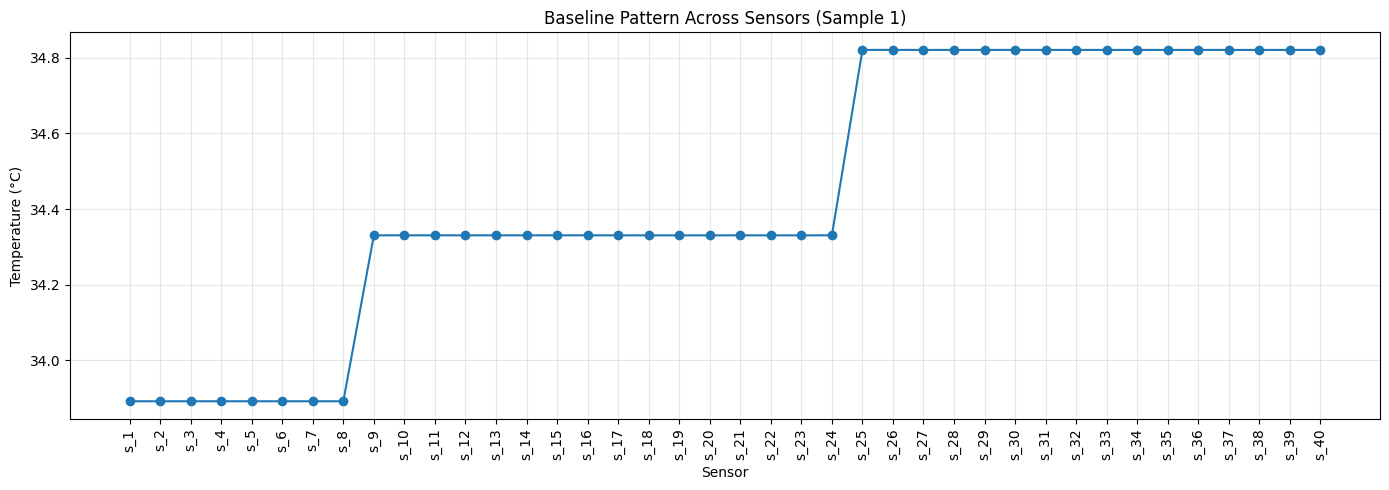

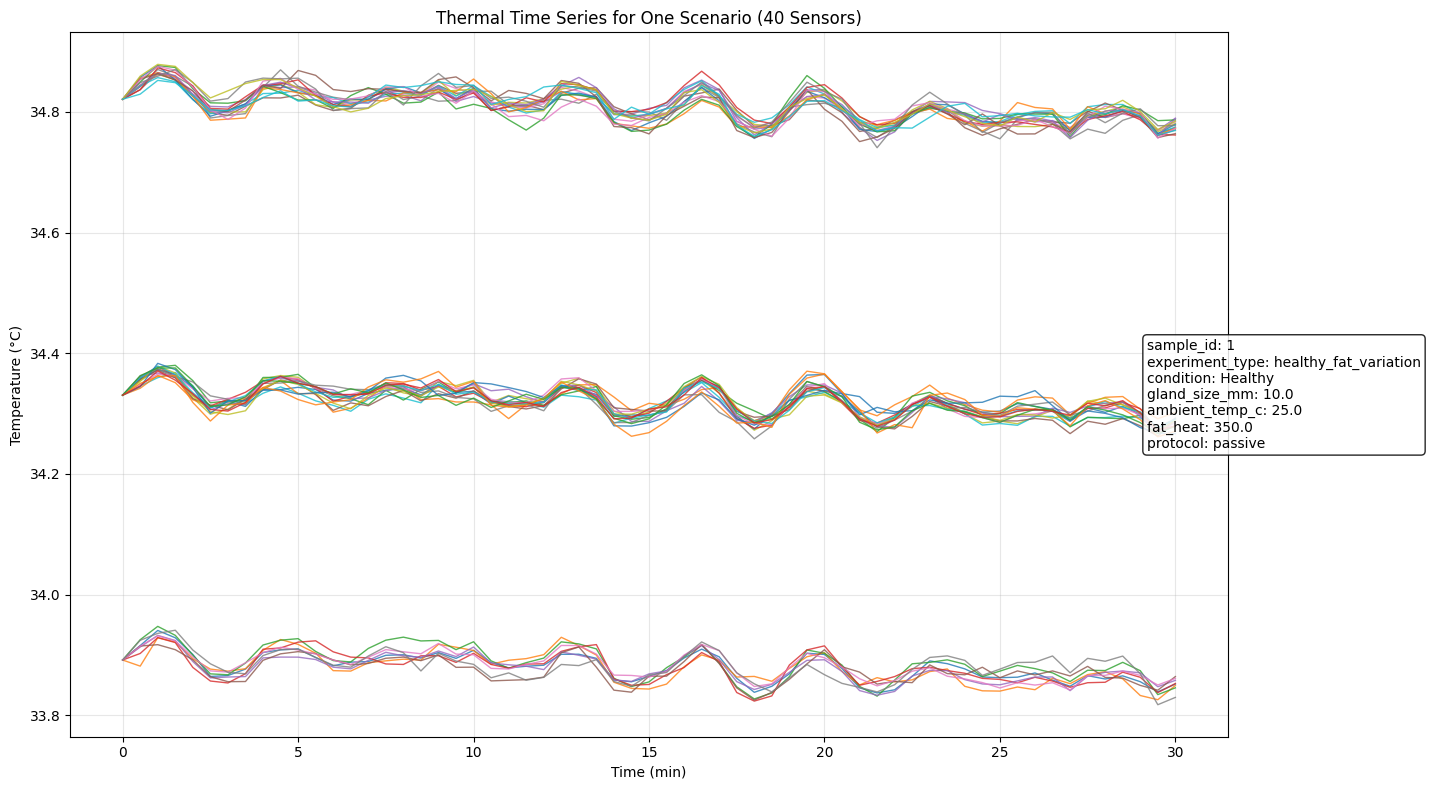

In [ ]:
# @title
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# USER INPUT
# =========================================================
ROOT = "/content/drive/MyDrive/FYP Breast Cancer Detection/Data - Code/Breast Cancer/Transformed data TS - TS+STIMULUS"

MATRIX_PATH = os.path.join(
    ROOT,
    "constructed_passive_matrix_dataset",
    "scenario_matrices_npy",
    "sample_0001.npy"
)

METADATA_PATH = os.path.join(
    ROOT,
    "constructed_passive_matrix_dataset",
    "metadata.csv"
)

TIME_GRID_PATH = os.path.join(
    ROOT,
    "constructed_passive_matrix_dataset",
    "time_grid.json"
)

# Original baseline dataset
BASE_WIDE_CSV = os.path.join(
    ROOT,
    "constructed_40_sensor_dataset",
    "breast_40_sensors_dataset.csv"
)

# Plot settings
FIGSIZE_TS = (16, 8)
FIGSIZE_BASELINE = (14, 5)
SHOW_LEGEND = False
LINE_ALPHA = 0.8
LINE_WIDTH = 1.0


# =========================================================
# HELPERS
# =========================================================
def extract_sample_id_from_path(path):
    fname = os.path.basename(path)
    m = re.search(r"sample_(\d+)", fname)
    return int(m.group(1)) if m else None


def load_matrix(matrix_path):
    ext = os.path.splitext(matrix_path)[1].lower()

    if ext == ".npy":
        mat = np.load(matrix_path)
        if mat.ndim != 2:
            raise ValueError(f"Expected a 2D matrix in {matrix_path}, got shape {mat.shape}")
        return mat

    elif ext == ".csv":
        df = pd.read_csv(matrix_path)
        if "time_index" in df.columns:
            df = df.drop(columns=["time_index"])
        return df.to_numpy(dtype=float)

    else:
        raise ValueError("Unsupported file type. Use .npy or .csv")


def load_time_axis(n_steps, time_grid_path=None):
    if time_grid_path is not None and os.path.exists(time_grid_path):
        with open(time_grid_path, "r", encoding="utf-8") as f:
            tg = json.load(f)

        if "time_min" in tg and len(tg["time_min"]) == n_steps:
            return np.array(tg["time_min"], dtype=float), "Time (min)"
        if "time_sec" in tg and len(tg["time_sec"]) == n_steps:
            return np.array(tg["time_sec"], dtype=float), "Time (sec)"

    return np.arange(n_steps), "Time index"


def load_metadata_for_sample(metadata_path, sample_id):
    if metadata_path is None or not os.path.exists(metadata_path) or sample_id is None:
        return None
    meta = pd.read_csv(metadata_path)
    if "sample_id" not in meta.columns:
        return None
    row = meta.loc[meta["sample_id"] == sample_id]
    if row.empty:
        return None
    return row.iloc[0].to_dict()


def format_metadata_text(meta_dict):
    if not meta_dict:
        return "Metadata not found"

    keys_to_show = [
        "sample_id",
        "experiment_type",
        "condition",
        "gland_size_mm",
        "ambient_temp_c",
        "radius_mm",
        "tumor_x",
        "tumor_y",
        "tumor_z",
        "fat_heat",
        "gland_heat",
        "tum_heat",
        "t_r",
        "protocol",
    ]

    lines = []
    for key in keys_to_show:
        if key in meta_dict:
            val = meta_dict[key]
            if pd.isna(val):
                continue
            lines.append(f"{key}: {val}")

    return "\n".join(lines) if lines else "No metadata available"


def load_original_baseline(base_wide_csv, sample_id, n_sensors):
    if base_wide_csv is None or not os.path.exists(base_wide_csv) or sample_id is None:
        return None

    base_df = pd.read_csv(base_wide_csv)
    if "sample_id" not in base_df.columns:
        return None

    row = base_df.loc[base_df["sample_id"] == sample_id]
    if row.empty:
        return None

    sensor_cols = [f"s_{i}" for i in range(1, n_sensors + 1)]
    missing = [c for c in sensor_cols if c not in row.columns]
    if missing:
        return None

    return row.iloc[0][sensor_cols].to_numpy(dtype=float)


# =========================================================
# LOAD
# =========================================================
mat = load_matrix(MATRIX_PATH)
n_steps, n_sensors = mat.shape
sensor_names = [f"s_{i}" for i in range(1, n_sensors + 1)]

sample_id = extract_sample_id_from_path(MATRIX_PATH)
meta_dict = load_metadata_for_sample(METADATA_PATH, sample_id)
meta_text = format_metadata_text(meta_dict)

x, x_label = load_time_axis(n_steps, TIME_GRID_PATH)

matrix_t0 = mat[0, :].copy()
original_baseline = load_original_baseline(BASE_WIDE_CSV, sample_id, n_sensors)

print("Matrix shape:", mat.shape)
print("Sample ID:", sample_id)

# =========================================================
# PRINT BASELINE
# =========================================================
baseline_source = "original wide dataset" if original_baseline is not None else "matrix first row"
baseline = original_baseline if original_baseline is not None else matrix_t0

baseline_df = pd.DataFrame({
    "sensor": sensor_names,
    "baseline_temp_c": baseline
})

print("\n===== BASELINE VALUES =====")
print(f"Baseline source: {baseline_source}")
print(baseline_df.to_string(index=False))

print("\n===== BASELINE SUMMARY =====")
print(baseline_df["baseline_temp_c"].describe())

if original_baseline is not None:
    compare_df = pd.DataFrame({
        "sensor": sensor_names,
        "original_baseline_c": original_baseline,
        "matrix_t0_c": matrix_t0,
        "difference_original_minus_t0": original_baseline - matrix_t0
    })
    print("\n===== ORIGINAL BASELINE VS MATRIX t=0 =====")
    print(compare_df.head(10).to_string(index=False))


# =========================================================
# BASELINE PLOT
# =========================================================
plt.figure(figsize=FIGSIZE_BASELINE)
plt.plot(sensor_names, baseline, marker="o", linewidth=1.5)
plt.xticks(rotation=90)
plt.xlabel("Sensor")
plt.ylabel("Temperature (°C)")
plt.title(f"Baseline Pattern Across Sensors (Sample {sample_id})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================
# FULL TIME-SERIES PLOT
# =========================================================
plt.figure(figsize=FIGSIZE_TS)

for j in range(n_sensors):
    plt.plot(
        x,
        mat[:, j],
        label=sensor_names[j],
        alpha=LINE_ALPHA,
        linewidth=LINE_WIDTH
    )

plt.xlabel(x_label)
plt.ylabel("Temperature (°C)")
plt.title(f"Thermal Time Series for One Scenario ({n_sensors} Sensors)")
plt.grid(True, alpha=0.3)

if SHOW_LEGEND:
    plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=True)

plt.gcf().text(
    0.80 if SHOW_LEGEND else 0.72,
    0.50,
    meta_text,
    fontsize=10,
    va="center",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

plt.tight_layout(rect=[0, 0, 0.78 if not SHOW_LEGEND else 0.70, 1])
plt.show()

Matrix shape: (61, 40)
Sample ID: 1

===== BASELINE VALUES =====
Baseline source: original wide dataset
sensor  baseline_temp_c
   s_1        33.891565
   s_2        33.891511
   s_3        33.891563
   s_4        33.891563
   s_5        33.891510
   s_6        33.891530
   s_7        33.891547
   s_8        33.891568
   s_9        34.330472
  s_10        34.330477
  s_11        34.330470
  s_12        34.330485
  s_13        34.330495
  s_14        34.330511
  s_15        34.330492
  s_16        34.330490
  s_17        34.330420
  s_18        34.330467
  s_19        34.330410
  s_20        34.330429
  s_21        34.330470
  s_22        34.330403
  s_23        34.330414
  s_24        34.330494
  s_25        34.820928
  s_26        34.820951
  s_27        34.820898
  s_28        34.820905
  s_29        34.820916
  s_30        34.820931
  s_31        34.820931
  s_32        34.820888
  s_33        34.820927
  s_34        34.820907
  s_35        34.820892
  s_36        34.820902
  s_37  

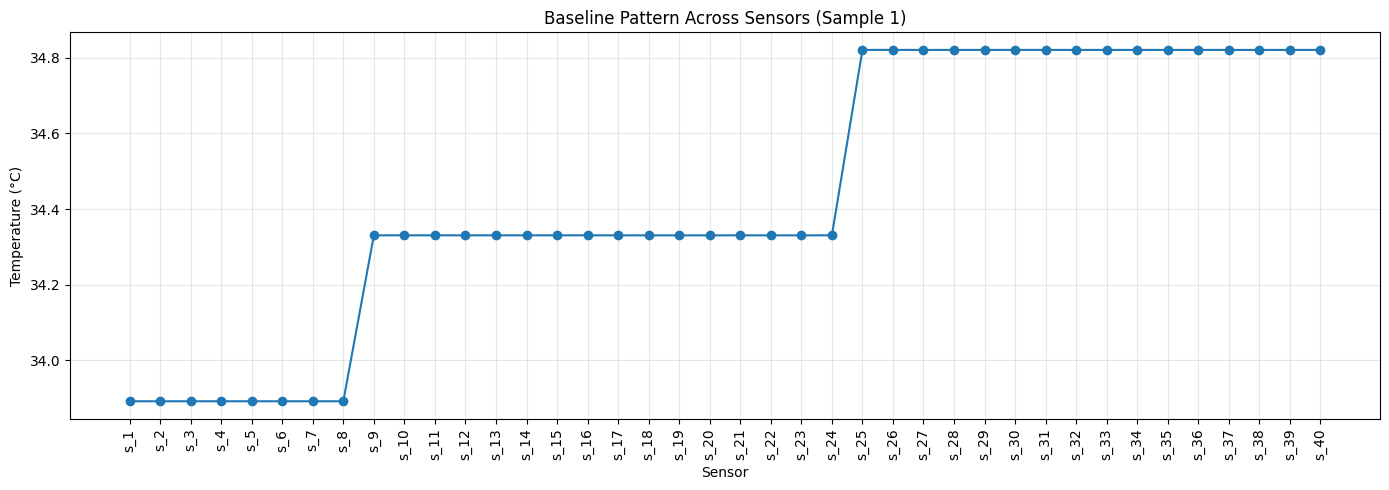

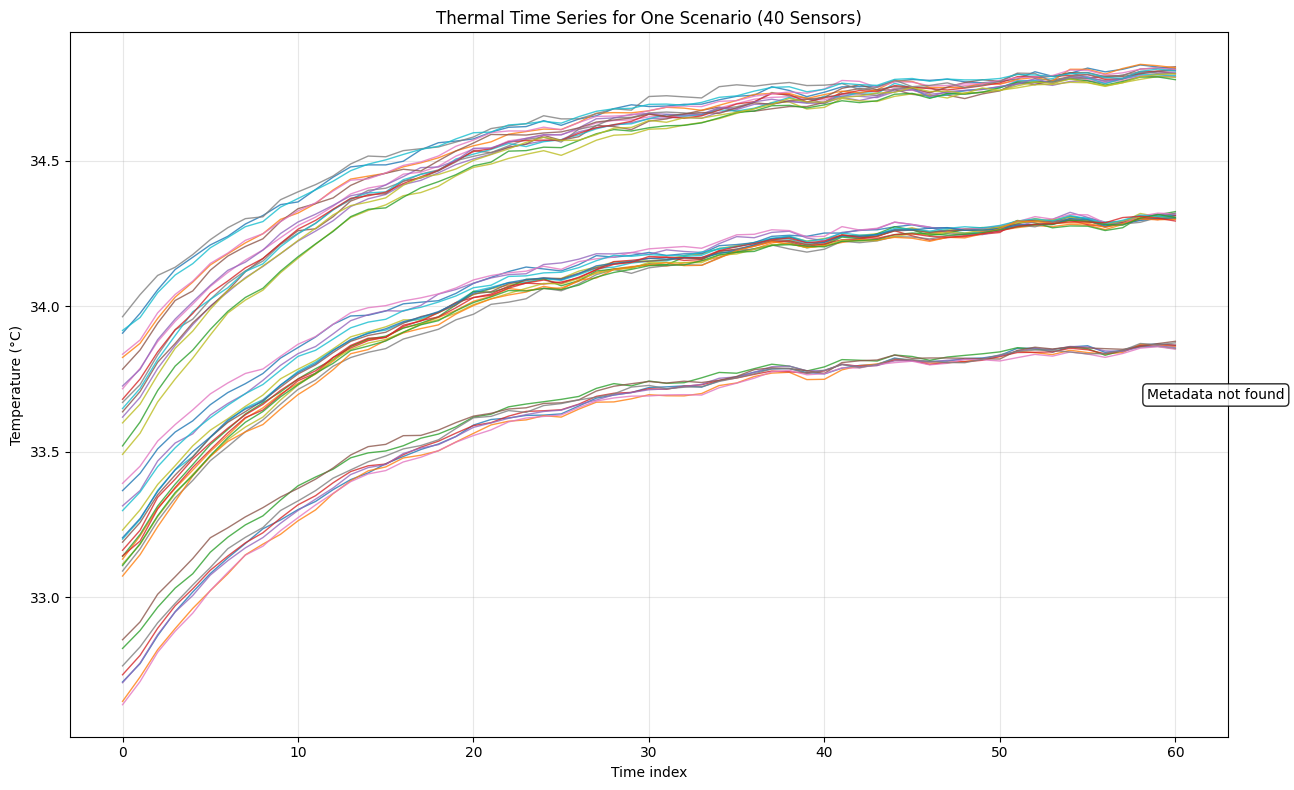

In [ ]:
# @title
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# USER INPUT
# =========================================================
ROOT = "/content/drive/MyDrive/FYP Breast Cancer Detection/Data - Code/Breast Cancer/Transformed data TS - TS+STIMULUS"

MATRIX_PATH = os.path.join(ROOT, "constructed_cooling_matrix_dataset", "cooling_scenario_matrices_npy", "sample_0001.npy")
METADATA_PATH = os.path.join(ROOT, "constructed_cooling_matrix_dataset", "cooling_metadata.csv")
TIME_GRID_PATH = os.path.join(ROOT, "constructed_cooling_matrix_dataset", "cooling_time_grid.json")
BASE_WIDE_CSV = os.path.join(ROOT, "constructed_40_sensor_dataset", "breast_40_sensors_dataset.csv")

# Plot settings
FIGSIZE_TS = (16, 8)
FIGSIZE_BASELINE = (14, 5)
SHOW_LEGEND = False
LINE_ALPHA = 0.8
LINE_WIDTH = 1.0


# =========================================================
# HELPERS
# =========================================================
def extract_sample_id_from_path(path):
    fname = os.path.basename(path)
    m = re.search(r"sample_(\d+)", fname)
    return int(m.group(1)) if m else None


def load_matrix(matrix_path):
    ext = os.path.splitext(matrix_path)[1].lower()

    if ext == ".npy":
        mat = np.load(matrix_path)
        if mat.ndim != 2:
            raise ValueError(f"Expected a 2D matrix in {matrix_path}, got shape {mat.shape}")
        return mat

    elif ext == ".csv":
        df = pd.read_csv(matrix_path)
        if "time_index" in df.columns:
            df = df.drop(columns=["time_index"])
        return df.to_numpy(dtype=float)

    else:
        raise ValueError("Unsupported file type. Use .npy or .csv")


def load_time_axis(n_steps, time_grid_path=None):
    if time_grid_path is not None and os.path.exists(time_grid_path):
        with open(time_grid_path, "r", encoding="utf-8") as f:
            tg = json.load(f)

        if "time_min" in tg and len(tg["time_min"]) == n_steps:
            return np.array(tg["time_min"], dtype=float), "Time (min)"
        if "time_sec" in tg and len(tg["time_sec"]) == n_steps:
            return np.array(tg["time_sec"], dtype=float), "Time (sec)"

    return np.arange(n_steps), "Time index"


def load_metadata_for_sample(metadata_path, sample_id):
    if metadata_path is None or not os.path.exists(metadata_path) or sample_id is None:
        return None
    meta = pd.read_csv(metadata_path)
    if "sample_id" not in meta.columns:
        return None
    row = meta.loc[meta["sample_id"] == sample_id]
    if row.empty:
        return None
    return row.iloc[0].to_dict()


def format_metadata_text(meta_dict):
    if not meta_dict:
        return "Metadata not found"

    keys_to_show = [
        "sample_id",
        "experiment_type",
        "condition",
        "gland_size_mm",
        "ambient_temp_c",
        "radius_mm",
        "tumor_x",
        "tumor_y",
        "tumor_z",
        "fat_heat",
        "gland_heat",
        "tum_heat",
        "t_r",
        "protocol",
    ]

    lines = []
    for key in keys_to_show:
        if key in meta_dict:
            val = meta_dict[key]
            if pd.isna(val):
                continue
            lines.append(f"{key}: {val}")

    return "\n".join(lines) if lines else "No metadata available"


def load_original_baseline(base_wide_csv, sample_id, n_sensors):
    if base_wide_csv is None or not os.path.exists(base_wide_csv) or sample_id is None:
        return None

    base_df = pd.read_csv(base_wide_csv)
    if "sample_id" not in base_df.columns:
        return None

    row = base_df.loc[base_df["sample_id"] == sample_id]
    if row.empty:
        return None

    sensor_cols = [f"s_{i}" for i in range(1, n_sensors + 1)]
    missing = [c for c in sensor_cols if c not in row.columns]
    if missing:
        return None

    return row.iloc[0][sensor_cols].to_numpy(dtype=float)


# =========================================================
# LOAD
# =========================================================
mat = load_matrix(MATRIX_PATH)
n_steps, n_sensors = mat.shape
sensor_names = [f"s_{i}" for i in range(1, n_sensors + 1)]

sample_id = extract_sample_id_from_path(MATRIX_PATH)
meta_dict = load_metadata_for_sample(METADATA_PATH, sample_id)
meta_text = format_metadata_text(meta_dict)

x, x_label = load_time_axis(n_steps, TIME_GRID_PATH)

matrix_t0 = mat[0, :].copy()
original_baseline = load_original_baseline(BASE_WIDE_CSV, sample_id, n_sensors)

print("Matrix shape:", mat.shape)
print("Sample ID:", sample_id)

# =========================================================
# PRINT BASELINE
# =========================================================
baseline_source = "original wide dataset" if original_baseline is not None else "matrix first row"
baseline = original_baseline if original_baseline is not None else matrix_t0

baseline_df = pd.DataFrame({
    "sensor": sensor_names,
    "baseline_temp_c": baseline
})

print("\n===== BASELINE VALUES =====")
print(f"Baseline source: {baseline_source}")
print(baseline_df.to_string(index=False))

print("\n===== BASELINE SUMMARY =====")
print(baseline_df["baseline_temp_c"].describe())

if original_baseline is not None:
    compare_df = pd.DataFrame({
        "sensor": sensor_names,
        "original_baseline_c": original_baseline,
        "matrix_t0_c": matrix_t0,
        "difference_original_minus_t0": original_baseline - matrix_t0
    })
    print("\n===== ORIGINAL BASELINE VS MATRIX t=0 =====")
    print(compare_df.head(10).to_string(index=False))


# =========================================================
# BASELINE PLOT
# =========================================================
plt.figure(figsize=FIGSIZE_BASELINE)
plt.plot(sensor_names, baseline, marker="o", linewidth=1.5)
plt.xticks(rotation=90)
plt.xlabel("Sensor")
plt.ylabel("Temperature (°C)")
plt.title(f"Baseline Pattern Across Sensors (Sample {sample_id})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================
# FULL TIME-SERIES PLOT
# =========================================================
plt.figure(figsize=FIGSIZE_TS)

for j in range(n_sensors):
    plt.plot(
        x,
        mat[:, j],
        label=sensor_names[j],
        alpha=LINE_ALPHA,
        linewidth=LINE_WIDTH
    )

plt.xlabel(x_label)
plt.ylabel("Temperature (°C)")
plt.title(f"Thermal Time Series for One Scenario ({n_sensors} Sensors)")
plt.grid(True, alpha=0.3)

if SHOW_LEGEND:
    plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=True)

plt.gcf().text(
    0.80 if SHOW_LEGEND else 0.72,
    0.50,
    meta_text,
    fontsize=10,
    va="center",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

plt.tight_layout(rect=[0, 0, 0.78 if not SHOW_LEGEND else 0.70, 1])
plt.show()

Matrix shape: (61, 40)
Sample ID: 191

===== BASELINE VALUES =====
Baseline source: original wide dataset
sensor  baseline_temp_c
   s_1        34.520523
   s_2        34.520514
   s_3        34.520533
   s_4        34.520532
   s_5        34.520520
   s_6        34.520506
   s_7        34.520503
   s_8        34.520531
   s_9        34.861517
  s_10        34.861546
  s_11        34.861473
  s_12        34.861480
  s_13        34.861466
  s_14        34.861532
  s_15        34.861562
  s_16        34.861539
  s_17        34.861535
  s_18        34.861569
  s_19        34.861558
  s_20        34.861514
  s_21        34.861503
  s_22        34.861521
  s_23        34.861481
  s_24        34.861534
  s_25        35.252610
  s_26        35.252583
  s_27        35.252549
  s_28        35.252541
  s_29        35.252583
  s_30        35.252561
  s_31        35.252589
  s_32        35.252591
  s_33        35.252625
  s_34        35.252609
  s_35        35.252570
  s_36        35.252607
  s_37

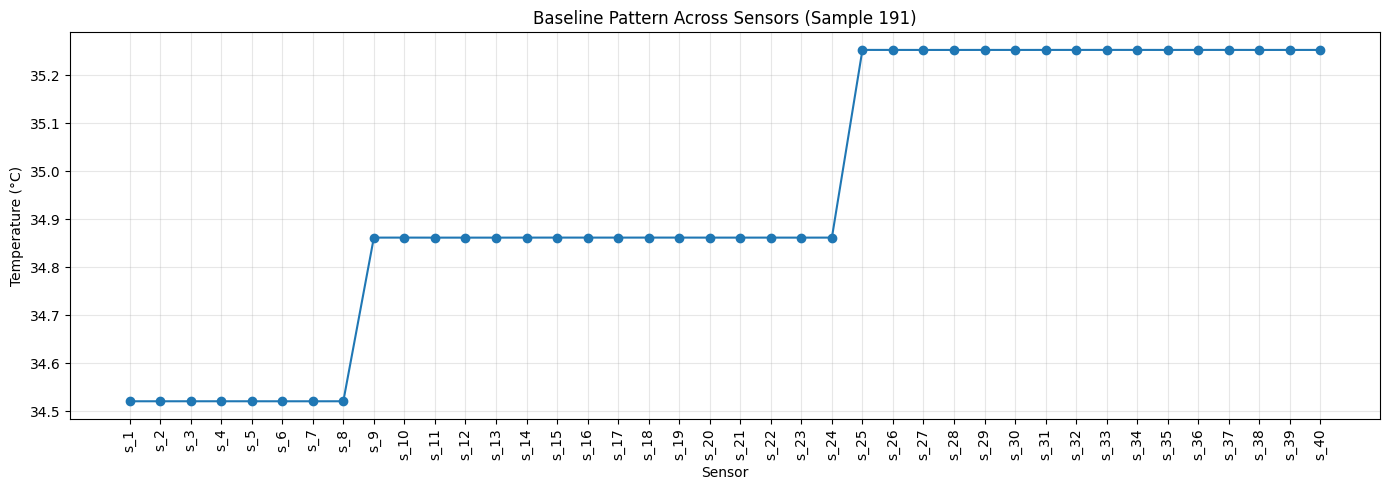

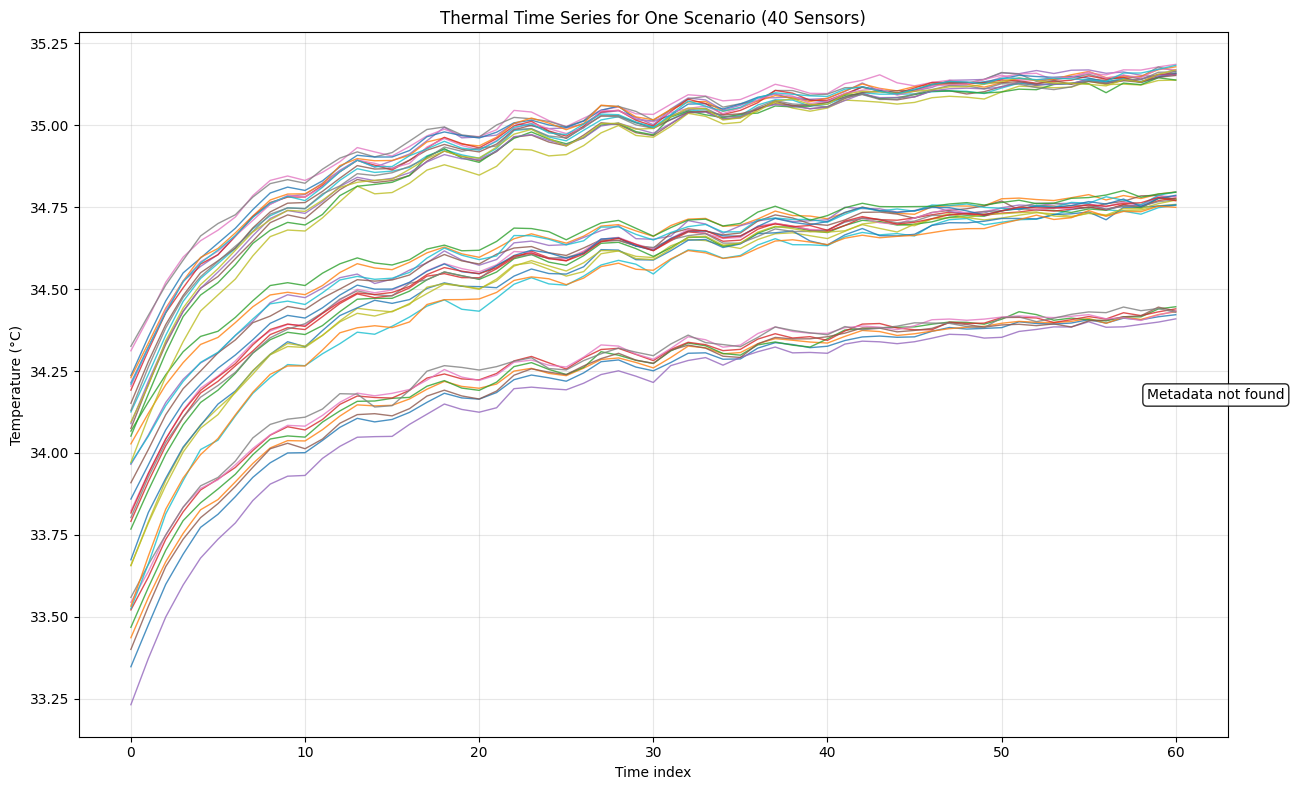

In [ ]:
# @title
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# USER INPUT
# =========================================================
ROOT = "/content/drive/MyDrive/FYP Breast Cancer Detection/Data - Code/Breast Cancer/Transformed data TS - TS+STIMULUS"

MATRIX_PATH = os.path.join(ROOT, "constructed_cooling_matrix_dataset", "cooling_scenario_matrices_npy", "sample_0191.npy")
METADATA_PATH = os.path.join(ROOT, "constructed_cooling_matrix_dataset", "cooling_metadata.csv")
TIME_GRID_PATH = os.path.join(ROOT, "constructed_cooling_matrix_dataset", "cooling_time_grid.json")
BASE_WIDE_CSV = os.path.join(ROOT, "constructed_40_sensor_dataset", "breast_40_sensors_dataset.csv")

# Plot settings
FIGSIZE_TS = (16, 8)
FIGSIZE_BASELINE = (14, 5)
SHOW_LEGEND = False
LINE_ALPHA = 0.8
LINE_WIDTH = 1.0


# =========================================================
# HELPERS
# =========================================================
def extract_sample_id_from_path(path):
    fname = os.path.basename(path)
    m = re.search(r"sample_(\d+)", fname)
    return int(m.group(1)) if m else None


def load_matrix(matrix_path):
    ext = os.path.splitext(matrix_path)[1].lower()

    if ext == ".npy":
        mat = np.load(matrix_path)
        if mat.ndim != 2:
            raise ValueError(f"Expected a 2D matrix in {matrix_path}, got shape {mat.shape}")
        return mat

    elif ext == ".csv":
        df = pd.read_csv(matrix_path)
        if "time_index" in df.columns:
            df = df.drop(columns=["time_index"])
        return df.to_numpy(dtype=float)

    else:
        raise ValueError("Unsupported file type. Use .npy or .csv")


def load_time_axis(n_steps, time_grid_path=None):
    if time_grid_path is not None and os.path.exists(time_grid_path):
        with open(time_grid_path, "r", encoding="utf-8") as f:
            tg = json.load(f)

        if "time_min" in tg and len(tg["time_min"]) == n_steps:
            return np.array(tg["time_min"], dtype=float), "Time (min)"
        if "time_sec" in tg and len(tg["time_sec"]) == n_steps:
            return np.array(tg["time_sec"], dtype=float), "Time (sec)"

    return np.arange(n_steps), "Time index"


def load_metadata_for_sample(metadata_path, sample_id):
    if metadata_path is None or not os.path.exists(metadata_path) or sample_id is None:
        return None
    meta = pd.read_csv(metadata_path)
    if "sample_id" not in meta.columns:
        return None
    row = meta.loc[meta["sample_id"] == sample_id]
    if row.empty:
        return None
    return row.iloc[0].to_dict()


def format_metadata_text(meta_dict):
    if not meta_dict:
        return "Metadata not found"

    keys_to_show = [
        "sample_id",
        "experiment_type",
        "condition",
        "gland_size_mm",
        "ambient_temp_c",
        "radius_mm",
        "tumor_x",
        "tumor_y",
        "tumor_z",
        "fat_heat",
        "gland_heat",
        "tum_heat",
        "t_r",
        "protocol",
    ]

    lines = []
    for key in keys_to_show:
        if key in meta_dict:
            val = meta_dict[key]
            if pd.isna(val):
                continue
            lines.append(f"{key}: {val}")

    return "\n".join(lines) if lines else "No metadata available"


def load_original_baseline(base_wide_csv, sample_id, n_sensors):
    if base_wide_csv is None or not os.path.exists(base_wide_csv) or sample_id is None:
        return None

    base_df = pd.read_csv(base_wide_csv)
    if "sample_id" not in base_df.columns:
        return None

    row = base_df.loc[base_df["sample_id"] == sample_id]
    if row.empty:
        return None

    sensor_cols = [f"s_{i}" for i in range(1, n_sensors + 1)]
    missing = [c for c in sensor_cols if c not in row.columns]
    if missing:
        return None

    return row.iloc[0][sensor_cols].to_numpy(dtype=float)


# =========================================================
# LOAD
# =========================================================
mat = load_matrix(MATRIX_PATH)
n_steps, n_sensors = mat.shape
sensor_names = [f"s_{i}" for i in range(1, n_sensors + 1)]

sample_id = extract_sample_id_from_path(MATRIX_PATH)
meta_dict = load_metadata_for_sample(METADATA_PATH, sample_id)
meta_text = format_metadata_text(meta_dict)

x, x_label = load_time_axis(n_steps, TIME_GRID_PATH)

matrix_t0 = mat[0, :].copy()
original_baseline = load_original_baseline(BASE_WIDE_CSV, sample_id, n_sensors)

print("Matrix shape:", mat.shape)
print("Sample ID:", sample_id)

# =========================================================
# PRINT BASELINE
# =========================================================
baseline_source = "original wide dataset" if original_baseline is not None else "matrix first row"
baseline = original_baseline if original_baseline is not None else matrix_t0

baseline_df = pd.DataFrame({
    "sensor": sensor_names,
    "baseline_temp_c": baseline
})

print("\n===== BASELINE VALUES =====")
print(f"Baseline source: {baseline_source}")
print(baseline_df.to_string(index=False))

print("\n===== BASELINE SUMMARY =====")
print(baseline_df["baseline_temp_c"].describe())

if original_baseline is not None:
    compare_df = pd.DataFrame({
        "sensor": sensor_names,
        "original_baseline_c": original_baseline,
        "matrix_t0_c": matrix_t0,
        "difference_original_minus_t0": original_baseline - matrix_t0
    })
    print("\n===== ORIGINAL BASELINE VS MATRIX t=0 =====")
    print(compare_df.head(10).to_string(index=False))


# =========================================================
# BASELINE PLOT
# =========================================================
plt.figure(figsize=FIGSIZE_BASELINE)
plt.plot(sensor_names, baseline, marker="o", linewidth=1.5)
plt.xticks(rotation=90)
plt.xlabel("Sensor")
plt.ylabel("Temperature (°C)")
plt.title(f"Baseline Pattern Across Sensors (Sample {sample_id})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================
# FULL TIME-SERIES PLOT
# =========================================================
plt.figure(figsize=FIGSIZE_TS)

for j in range(n_sensors):
    plt.plot(
        x,
        mat[:, j],
        label=sensor_names[j],
        alpha=LINE_ALPHA,
        linewidth=LINE_WIDTH
    )

plt.xlabel(x_label)
plt.ylabel("Temperature (°C)")
plt.title(f"Thermal Time Series for One Scenario ({n_sensors} Sensors)")
plt.grid(True, alpha=0.3)

if SHOW_LEGEND:
    plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=True)

plt.gcf().text(
    0.80 if SHOW_LEGEND else 0.72,
    0.50,
    meta_text,
    fontsize=10,
    va="center",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

plt.tight_layout(rect=[0, 0, 0.78 if not SHOW_LEGEND else 0.70, 1])
plt.show()